In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
train_dir = "dataset/Training"
test_dir = "dataset/Testing"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [3]:
from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [4]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=['glioma','meningioma','pituitary','notumor'],
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=['glioma','meningioma','pituitary','notumor'],
    class_mode='categorical',
    shuffle=False
)

Found 5605 images belonging to 4 classes.
Found 1611 images belonging to 4 classes.


In [5]:
base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])

I0000 00:00:1776623704.729167     746 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1765 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [6]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10
)

Epoch 1/10


2026-04-19 18:35:12.354491: I external/local_xla/xla/service/service.cc:163] XLA service 0x779fe804aab0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-19 18:35:12.354537: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2026-04-19 18:35:12.637072: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-19 18:35:14.285913: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-04-19 18:35:13.953831: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-19 18:35:15.

 90/176 ━━━━━━━━━━━━━━━━━━━━ 15s 176ms/step - accuracy: 0.4876 - loss: 1.4221

2026-04-19 18:36:00.325162: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 18:36:00.546627: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 18:36:01.758719: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 18:36:02.054915: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 18:36:02.861658: E external/local_xla/xla/stream_

176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.5661 - loss: 1.1995

2026-04-19 18:36:41.074758: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 18:36:41.299135: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 18:36:42.509521: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 18:36:42.750935: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 18:36:43.575686: E external/local_xla/xla/stream_

176/176 ━━━━━━━━━━━━━━━━━━━━ 101s 412ms/step - accuracy: 0.6794 - loss: 0.8769 - val_accuracy: 0.7536 - val_loss: 0.6404
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 34s 194ms/step - accuracy: 0.7905 - loss: 0.5716 - val_accuracy: 0.7983 - val_loss: 0.5648
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 33s 186ms/step - accuracy: 0.8314 - loss: 0.4639 - val_accuracy: 0.8293 - val_loss: 0.5297
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 33s 187ms/step - accuracy: 0.8434 - loss: 0.4211 - val_accuracy: 0.8417 - val_loss: 0.5190
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 33s 185ms/step - accuracy: 0.8696 - loss: 0.3581 - val_accuracy: 0.8541 - val_loss: 0.5002
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 34s 191ms/step - accuracy: 0.8673 - loss: 0.3424 - val_accuracy: 0.8560 - val_loss: 0.4886
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 33s 185ms/step - accuracy: 0.8776 - loss: 0.3218 - val_accuracy: 0.8678 - val_loss: 0.4625
Epoch 8/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 32s 181ms/step - accuracy: 0.8871 - loss: 0.3030 - va

In [8]:
model.evaluate(test_generator)

51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.8727 - loss: 0.4450


[0.44502508640289307, 0.8727498650550842]

In [9]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2)

history_fine = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=5,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/5


2026-04-19 18:41:58.775698: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 18:41:59.043245: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


176/176 ━━━━━━━━━━━━━━━━━━━━ 72s 303ms/step - accuracy: 0.7829 - loss: 0.5711 - val_accuracy: 0.8479 - val_loss: 0.4958 - learning_rate: 1.0000e-05
Epoch 2/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 33s 186ms/step - accuracy: 0.8275 - loss: 0.4615 - val_accuracy: 0.8436 - val_loss: 0.5286 - learning_rate: 1.0000e-05
Epoch 3/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 33s 187ms/step - accuracy: 0.8369 - loss: 0.4115 - val_accuracy: 0.8473 - val_loss: 0.5237 - learning_rate: 1.0000e-05
Epoch 4/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 33s 189ms/step - accuracy: 0.8560 - loss: 0.3789 - val_accuracy: 0.8461 - val_loss: 0.5282 - learning_rate: 3.0000e-06


51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 130ms/step


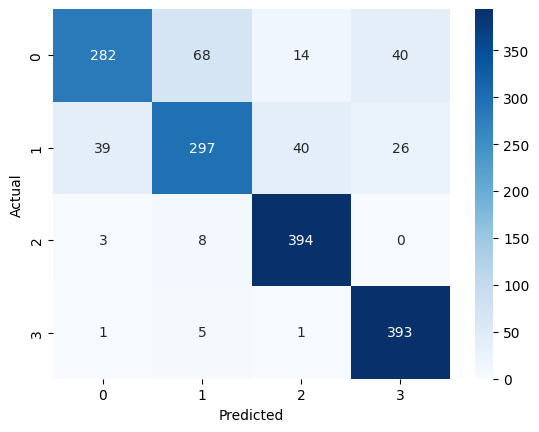

              precision    recall  f1-score   support

           0       0.87      0.70      0.77       404
           1       0.79      0.74      0.76       402
           2       0.88      0.97      0.92       405
           3       0.86      0.98      0.92       400

    accuracy                           0.85      1611
   macro avg       0.85      0.85      0.84      1611
weighted avg       0.85      0.85      0.84      1611



In [11]:
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred_classes)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_true, y_pred_classes))

## Different version

In [4]:
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras import Model, Input

base_model = EfficientNetB3(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

inputs = Input(shape=(224,224,3))
x = base_model(inputs)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(512, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(4, activation='softmax')(x)

model = Model(inputs, outputs)

In [5]:
from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

traingenerator = train_datagen.flow_from_directory(
    'dataset/Training',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    classes=['glioma','meningioma','pituitary','notumor']  # ignore others
)

testgenerator = train_datagen.flow_from_directory(
    'dataset/Training',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    classes=['glioma','meningioma','pituitary','notumor'],
    shuffle=False
)


print(traingenerator.class_indices)

Found 4485 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
{'glioma': 0, 'meningioma': 1, 'pituitary': 2, 'notumor': 3}


In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-7
    ),
    ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True
    )
]

In [7]:
from sklearn.utils.class_weight import compute_class_weight

y_train = traingenerator.classes


class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    traingenerator,
    validation_data=testgenerator,
    epochs=25,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/25


2026-04-21 13:59:19.848306: I external/local_xla/xla/service/service.cc:163] XLA service 0x7526400158a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-21 13:59:19.848364: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2026-04-21 13:59:20.340030: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-21 13:59:23.562225: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-04-21 13:59:25.253740: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-21 13:59:27.

 81/141 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - accuracy: 0.4928 - loss: 1.3964

2026-04-21 14:00:19.411231: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-21 14:00:19.678068: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-21 14:00:19.969255: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv (f32[5,816,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[5,816,14,14]{3,2,1,0}, f32[816,1,5,5]{3,2,1,0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, feature_group_count=816, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leak

141/141 ━━━━━━━━━━━━━━━━━━━━ 123s 531ms/step - accuracy: 0.6876 - loss: 0.8576 - val_accuracy: 0.8571 - val_loss: 0.4753 - learning_rate: 1.0000e-04
Epoch 2/25
141/141 ━━━━━━━━━━━━━━━━━━━━ 26s 185ms/step - accuracy: 0.8185 - loss: 0.4995 - val_accuracy: 0.8830 - val_loss: 0.3241 - learning_rate: 1.0000e-04
Epoch 3/25
141/141 ━━━━━━━━━━━━━━━━━━━━ 29s 208ms/step - accuracy: 0.8571 - loss: 0.3738 - val_accuracy: 0.8929 - val_loss: 0.2757 - learning_rate: 1.0000e-04
Epoch 4/25
141/141 ━━━━━━━━━━━━━━━━━━━━ 31s 219ms/step - accuracy: 0.8789 - loss: 0.3292 - val_accuracy: 0.9062 - val_loss: 0.2478 - learning_rate: 1.0000e-04
Epoch 5/25
141/141 ━━━━━━━━━━━━━━━━━━━━ 23s 158ms/step - accuracy: 0.8963 - loss: 0.2774 - val_accuracy: 0.9214 - val_loss: 0.2245 - learning_rate: 1.0000e-04
Epoch 6/25
141/141 ━━━━━━━━━━━━━━━━━━━━ 22s 158ms/step - accuracy: 0.9068 - loss: 0.2540 - val_accuracy: 0.9214 - val_loss: 0.2129 - learning_rate: 1.0000e-04
Epoch 7/25
141/141 ━━━━━━━━━━━━━━━━━━━━ 25s 177ms/step -

In [9]:
base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
from tensorflow.keras.metrics import Precision, Recall

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)

35/35 ━━━━━━━━━━━━━━━━━━━━ 20s 265ms/step


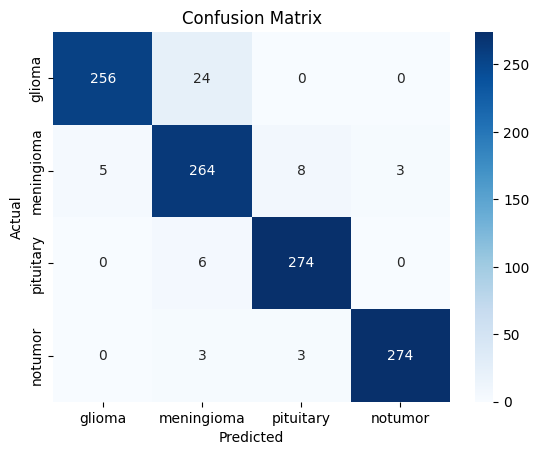

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

testgenerator.reset()
y_pred = model.predict(testgenerator)



y_pred_classes = np.argmax(y_pred, axis=1)




cm = confusion_matrix(testgenerator.classes, y_pred_classes)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['glioma','meningioma','pituitary','notumor'],
            yticklabels=['glioma','meningioma','pituitary','notumor'])

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [13]:
testgenerator.reset()

y_pred = model.predict(testgenerator, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(testgenerator.classes, y_pred_classes)

35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 140ms/step


In [14]:
testgenerator = train_datagen.flow_from_directory(
    'dataset/Training',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False   # 🚨 VERY IMPORTANT
)

Found 1120 images belonging to 5 classes.


In [ ]:
'best_model.keras'

In [15]:
model.save("best_model.keras")

# some testing

In [21]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load your trained model
model = tf.keras.models.load_model("best_model.keras")  # change path

# Test data path (IMPORTANT: same class folder structure)
test_dir = "dataset/Testing"   # e.g. test/Glioma, test/Meningioma...

from tensorflow.keras.applications.efficientnet import preprocess_input

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    classes=['glioma', 'meningioma', 'pituitary', 'notumor'],  # ✅ only these
    shuffle=False
)

# Evaluate
results = model.evaluate(test_gen)

print("Loss:", results[0])
print("Accuracy:", results[1])
print("Precision:", results[2])
print("Recall:", results[3])



Found 1611 images belonging to 4 classes.
51/51 ━━━━━━━━━━━━━━━━━━━━ 18s 196ms/step - accuracy: 0.9181 - loss: 0.3959 - precision: 0.9219 - recall: 0.9162
Loss: 0.3959137797355652
Accuracy: 0.9180633425712585
Precision: 0.921923816204071
Recall: 0.916201114654541


NameError: name 'accuracy' is not defined

51/51 ━━━━━━━━━━━━━━━━━━━━ 18s 224ms/step


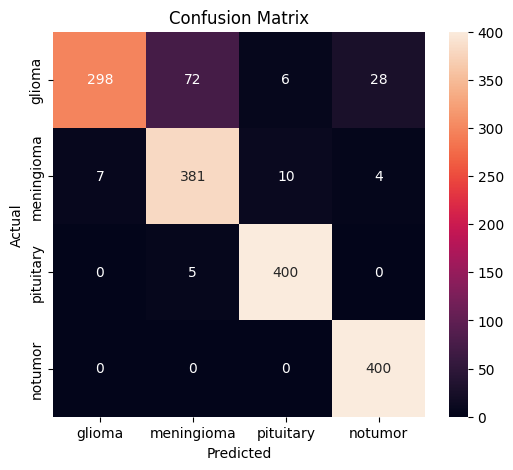


📊 Classification Report:

              precision    recall  f1-score   support

      glioma       0.98      0.74      0.84       404
  meningioma       0.83      0.95      0.89       402
   pituitary       0.96      0.99      0.97       405
     notumor       0.93      1.00      0.96       400

    accuracy                           0.92      1611
   macro avg       0.92      0.92      0.92      1611
weighted avg       0.92      0.92      0.92      1611



In [22]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes

# Class names
class_names = list(test_gen.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\n📊 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

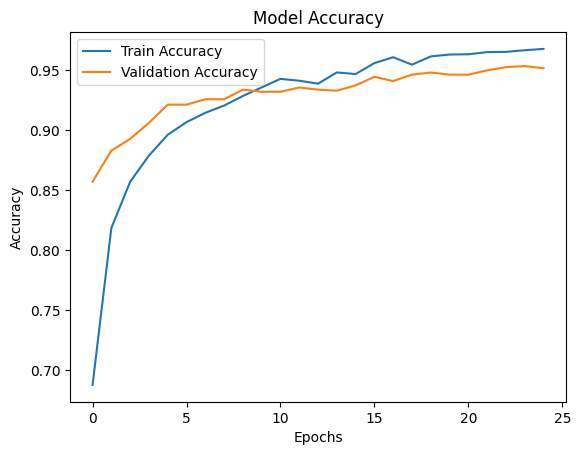

In [23]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Model Accuracy")
plt.show()

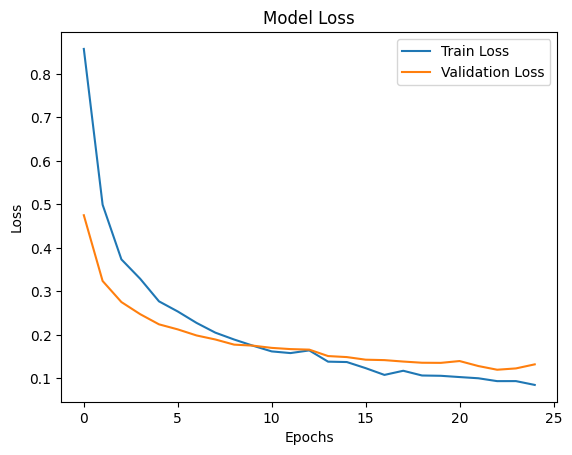

In [24]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Model Loss")
plt.show()